<a href="https://colab.research.google.com/github/sandotra1/Physics-Simulation-Collection/blob/main/MagneticResonance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Magnetic Resonance Simulation: Precession of Magnetization in a Magnetic Field

This simulation demonstrates the phenomenon of magnetic resonance, specifically the precession of a magnetization vector in the presence of a constant magnetic field.

### Key Concepts:
- **Magnetic Moment (Magnetization, M)**: A vector that represents the magnetic properties of a particle, atom, or material. In this simulation, the magnetization vector is initially aligned along the x-axis.
- **Magnetic Field (B)**: A constant external field that affects the orientation of the magnetization. In this case, the field is applied along the z-axis.
- **Precession**: The rotation of the magnetization vector around the magnetic field. This occurs due to the torque exerted on the magnetic moment by the magnetic field, causing the vector to rotate in a circular path.
- **Gyromagnetic Ratio (γ)**: This determines how strongly the magnetization responds to the magnetic field.

### Simulation Overview:
- In this simulation, the magnetization vector starts aligned with the x-axis, and as time progresses, it begins to precess around the z-axis under the influence of the magnetic field.
- The path of the magnetization is traced, and you can observe how the vector rotates in the xy-plane.


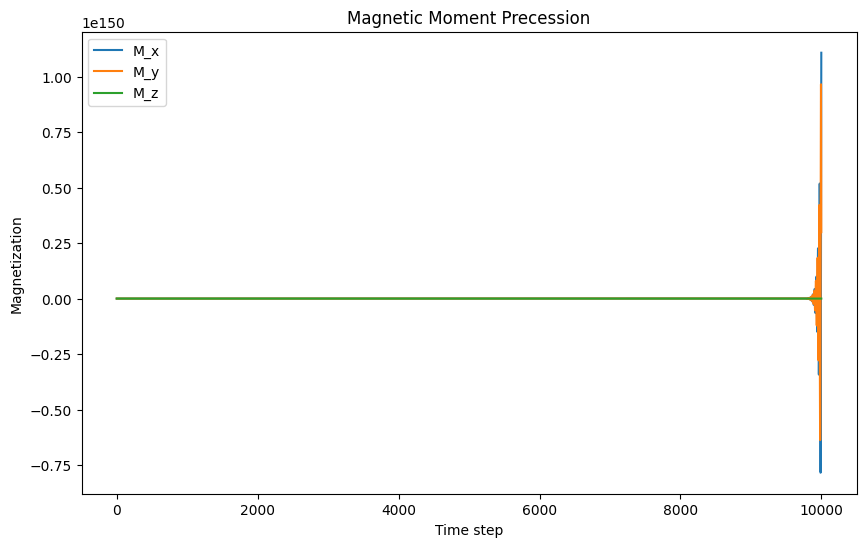

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_magnetic_resonance(M0, B, gamma, dt, steps):
    # Initialize an array to store the magnetization vector at each time step
    M = np.zeros((steps, 3))
    M[0] = M0

    # Euler integration loop
    for i in range(1, steps):
        dM = gamma * np.cross(M[i-1], B)
        M[i] = M[i-1] + dM * dt

    return M

# Parameters
gamma = 2.675e8  # Gyromagnetic ratio in rad/s/T (for protons)
B = np.array([0, 0, 1])  # Constant magnetic field along the z-axis (in Tesla)
M0 = np.array([1, 0, 0])  # Initial magnetization vector (starting along x-axis)
dt = 1e-9  # Time step in seconds
steps = 10000  # Number of simulation steps

# Run the simulation
M = simulate_magnetic_resonance(M0, B, gamma, dt, steps)

# Plot the magnetization components over time
plt.figure(figsize=(10, 6))
plt.plot(M[:, 0], label='M_x')
plt.plot(M[:, 1], label='M_y')
plt.plot(M[:, 2], label='M_z')
plt.xlabel('Time step')
plt.ylabel('Magnetization')
plt.legend()
plt.title('Magnetic Moment Precession')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def simulate_magnetic_resonance(M0, B, gamma, dt, steps):
    M = np.zeros((steps, 3))
    M[0] = M0
    for i in range(1, steps):
        dM = gamma * np.cross(M[i-1], B)
        M[i] = M[i-1] + dM * dt
        M[i] /= np.linalg.norm(M[i])  # Keep the magnetization vector normalized
    return M

# Simulation parameters
gamma = 2.675e8         # Gyromagnetic ratio (rad/s/T)
B = np.array([0, 0, 1]) # Magnetic field along z-axis (Tesla)
M0 = np.array([1, 0, 0]) # Initial magnetization along x-axis
dt = 1e-9               # Time step (seconds)
steps = 2000            # Total simulation steps

# Generate simulation data
M = simulate_magnetic_resonance(M0, B, gamma, dt, steps)

# Set up the 3D plot
fig = plt.figure(figsize=(6,6), dpi=80)
ax = fig.add_subplot(111, projection='3d')

# Fixed plot limits so nothing goes offscreen
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Magnetic Resonance: Magnetization Precession")

# Initialize the point and trajectory line
point, = ax.plot([], [], [], 'ro', markersize=12, zorder=5) # Red dot
line, = ax.plot([], [], [], lw=2, color='blue', zorder=1)   # Blue trajectory

# Add the magnetic field vector (represented by an arrow)
ax.quiver(0, 0, 0, B[0], B[1], B[2], color='g', length=0.8, lw=2, label="Magnetic Field B")

def init():
    point.set_data([], [])
    point.set_3d_properties([])
    line.set_data([], [])
    line.set_3d_properties([])
    return point, line

def update(frame):
    current_M = M[:frame+1]

    # Update red dot's position
    point.set_data([current_M[-1, 0]], [current_M[-1, 1]])
    point.set_3d_properties([current_M[-1, 2]])

    # Update blue line (trajectory)
    line.set_data(current_M[:, 0], current_M[:, 1])
    line.set_3d_properties(current_M[:, 2])
    return point, line

# Slow down the animation by increasing the interval between frames
ani = FuncAnimation(fig, update, frames=range(0, steps, 50),
                    init_func=init, interval=100)  # Adjust this value to slow down (in milliseconds)

plt.close(fig) # <<< This ensures no extra static plot shows up
HTML(ani.to_jshtml())



